In [ ]:
import torch as tc
import numpy as np
import matplotlib.pyplot as plt
from fun import Rede,SIN
from tqdm import tqdm
import math
import qutip as qt
from qutip import destroy, hinton, basis, mesolve, qeye

In [25]:
def simulate_transmon(t_points):
    # Parâmetros do Transmon (em unidades de GHz, por exemplo)
    N = 5  # Número de níveis
    f_q = 5.0  # Frequência do qubit (0 -> 1) em GHz
    alpha = -0.3  # Anarmonicidade em GHz (típico para transmons)

    # Operadores
    a = destroy(N)
    adag = a.dag()

    # Hamiltoniano do Transmon (Duffing Oscillator)
    # H = f_q * a.dag() * a + (alpha/2) * a.dag() * a.dag() * a * a
    H0 = f_q * adag * a + (alpha / 2.0)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a) #

    # 1. Calcular Níveis de Energia
    Omega = 1.0  # Força do drive (Rabi frequency) em GHz
    H_drive = Omega * (a + adag)

    # Hamiltoniano total
    # H = [H0, [H_drive, w0]]
    H = H0+H_drive
    args = {'wd': f_q}

    # Estado inicial: fundamental |0>
    psi0 = basis(N, 0)

    # Resolver a equação de mestre (sem dissipação por enquanto)
    result = mesolve(H, psi0, t_points, [], [basis(N, i) * basis(N, i).dag() for i in range(N)], args=args)
    expect = tc.tensor( np.array( result.expect)).transpose(0, 1)
    return expect , H.eigenenergies()

In [ ]:
tfinal = 2.2
N      = 1000
Nedo   = 10
Nfield = 0

time =  np.linspace(0,tfinal, N)
data,energias = simulate_transmon(time)

In [27]:
neuronio = [50,50]

X_vector   = Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[SIN()]*len(neuronio))

opt = tc.optim.Adam(X_vector.parameters(),
        lr = 0.001)
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

100%|██████████| 20000/20000 [05:09<00:00, 64.71it/s]


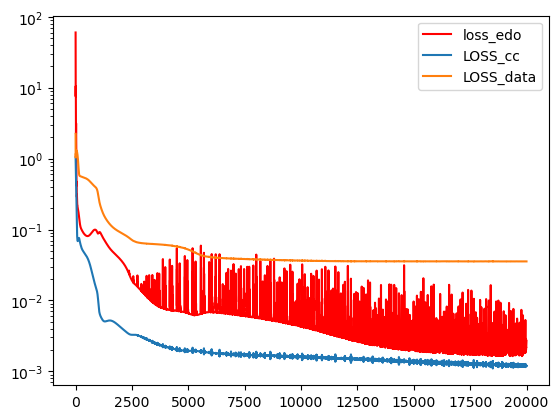

In [28]:
epocas  = 20000
factor_time = 1
# Frequência do Qubit (f_q) usada no QuTiP
f_q = 5.0 * factor_time 

# As energias diagonais devem ser puramente os níveis do oscilador harmônico (n * f_q)
E0 = 0.0 * f_q
E1 = 1.0 * f_q
E2 = 2.0 * f_q
E3 = 3.0 * f_q
E4 = 4.0 * f_q

# O resto continua igual
alfa = -0.3 * factor_time
wt = tc.ones(len(time)).reshape((-1, 1))

LOSS    = []
LOSS1   = []
LOSS2   = []
LOSS3   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y  = X_vector(time)

    ######## Los edo #######
    term1 = []
    for i in range(y.shape[1]):
        term1.append(tc.autograd.grad(outputs = y[:, i],
                                    inputs = time,
                                    grad_outputs = tc.ones_like(y[:, i]),
                                    #retain_graph = True,
                                    create_graph = True)[0])
    term1   = tc.cat(term1, dim=1)

    I0 = y[:, 0:1]
    I1 = y[:, 1:2]
    I2 = y[:, 2:3]
    I3 = y[:, 3:4]
    I4 = y[:, 4:5]
    R0 = y[:, 5:6]
    R1 = y[:, 6:7]
    R2 = y[:, 7:8]
    R3 = y[:, 8:9]
    R4 = y[:, 9:10]

    # Parte Real
    LOSS_edo = (term1[:, 0:1] +(E0*R0 + 1.5*alfa*R0+3*math.sqrt(2)*alfa*R2+math.sqrt(6)*alfa*R4 + wt*R1))**2
    LOSS_edo += (term1[:, 1:2]+(E1*R1 + 7.5*alfa*R1 +5*math.sqrt(6)*alfa*R3 + wt*(R0 + math.sqrt(2)*R2)))**2
    LOSS_edo += (term1[:, 2:3]+(E2*R2 +3*math.sqrt(2)*alfa*R0+ 19.5*alfa*R2 +9*math.sqrt(3)*alfa*R4 + wt*(math.sqrt(2)*R1+math.sqrt(3)*R3)))**2
    LOSS_edo += (term1[:, 3:4]+(E3*R3 +5*math.sqrt(6)*alfa*R1+ 27.5*alfa*R3+ wt*(math.sqrt(3)*R2+math.sqrt(4)*R4)))**2
    LOSS_edo += (term1[:, 4:5]+(E4*R4 +math.sqrt(6)*alfa*R0+9*math.sqrt(3)*alfa*R2 + 14*alfa*R4 + wt*(math.sqrt(4)*R3)))**2

    # Parte Imaginária (Removido o + interno para evitar erro de UnaryOp)
    LOSS_edo += (term1[:, 5:6] -(E0*I0 + 1.5*alfa*I0+3*math.sqrt(2)*alfa*I2+math.sqrt(6)*alfa*I4 + wt*I1))**2
    LOSS_edo += (term1[:, 6:7] - (E1*I1 + 7.5*alfa*I1 +5*math.sqrt(6)*alfa*I3 + wt*(I0 + math.sqrt(2)*I2)))**2
    LOSS_edo += (term1[:, 7:8] - (E2*I2 +3*math.sqrt(2)*alfa*I0+ 19.5*alfa*I2 +9*math.sqrt(3)*alfa*I4 + wt*(math.sqrt(2)*I1+math.sqrt(3)*I3)))**2
    LOSS_edo += (term1[:, 8:9] - (E3*I3 +5*math.sqrt(6)*alfa*I1+ 27.5*alfa*I3+ wt*(math.sqrt(3)*I2+math.sqrt(4)*I4)))**2
    LOSS_edo += (term1[:, 9:10]-(E4*I4 +math.sqrt(6)*alfa*I0+9*math.sqrt(3)*alfa*I2 + 14*alfa*I4 + wt*(math.sqrt(4)*I3)))**2
    LOSS_edo = LOSS_edo.mean()

    ####### loss data(target conditions) #######
    LOSS_cc = (R0[0]  - 1)**2
    LOSS_cc += (R1[0]  - 0)**2
    LOSS_cc += (R2[0]  + 0)**2
    LOSS_cc += ((R3[0]  + 0)**2)
    LOSS_cc += ((R4[0]  + 0)**2)
    LOSS_cc += ((I0[0]  + 0)**2)
    LOSS_cc += ((I1[0]  + 0)**2)
    LOSS_cc += ((I2[0]  + 0)**2)
    LOSS_cc += ((I3[0]  + 0)**2)
    LOSS_cc += ((I4[0]  + 0)**2)
    LOSS_cc = LOSS_cc.mean()

    ####### loss data #######
    expect1 =  (I0)**2+(R0)**2
    expect2 =  (I1)**2+(R1)**2
    expect3 =  (I2)**2+(R2)**2
    expect4 =  (I3)**2+(R3)**2
    expect5 =  (I4)**2+(R4)**2
    
    LOSS_data  = (expect1 - data[:,0:1] )**2
    LOSS_data += (expect2 - data[:,1:2] )**2
    LOSS_data += 10*(expect3 - data[:,2:3] )**2
    LOSS_data += 30*(expect4 - data[:,3:4] )**2
    LOSS_data += 50*(expect5 - data[:,4:5] )**2
    LOSS_data = LOSS_data.mean()
    loss_i = LOSS_edo + LOSS_cc + LOSS_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()

    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_cc.cpu().detach().numpy())
    LOSS3.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="LOSS_cc")
plt.plot(LOSS3,label="LOSS_data")  
plt.yscale("log")   
plt.legend()
plt.show()


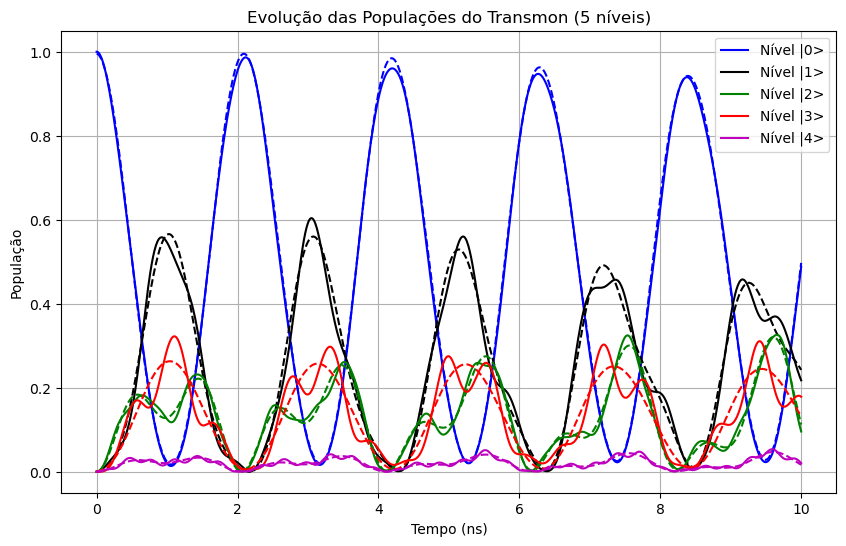

In [29]:
t_points = np.linspace(0, tfinal, N)
with tc.no_grad():
    X_ = X_vector(time).detach().cpu().numpy()
data,energias = simulate_transmon(t_points)

plt.figure(figsize=(10, 6))
plt.plot( t_points, 
         data[:,0:1],"b", label=f'Nível |{0}>')
plt.plot( t_points,
            (X_[:,0])**2 + (X_[:,5])**2,"b--")

plt.plot(t_points, 
         data[:,1:2],"k", label=f'Nível |{1}>')
plt.plot(t_points,
            (X_[:,1])**2 + (X_[:,6])**2,
            "k--")

plt.plot(t_points,
         data[:,2:3],"g", label=f'Nível |{2}>')
plt.plot(t_points,
            (X_[:,2])**2 + (X_[:,7])**2,
            "g--")

plt.plot(t_points, 
         data[:,3:4],"r", label=f'Nível |{3}>')
plt.plot(t_points,
            (X_[:,3])**2 + (X_[:,8])**2,"r--")

plt.plot(t_points, 
         data[:,4:5],"m", label=f'Nível |{4}>')
plt.plot(t_points,
            (X_[:,4])**2 + (X_[:,9])**2,"m--")

plt.title('Evolução das Populações do Transmon (5 níveis)')
plt.xlabel('Tempo (ns)')
plt.ylabel('População')
plt.legend()
plt.legend()
plt.grid(True)
plt.show()